# Iris Unsupervised Clustering (Multi-Criteria k Selection)

This notebook explores Iris using unsupervised methods only.
The target column is held out from all fitting steps and used
only for post-hoc evaluation metrics.

k is selected using a rank-based consensus of multiple unsupervised metrics
with an elbow-based tie-breaker.

In [13]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

project_root = Path.cwd()
if not (project_root / 'src').exists() and project_root.parent.exists():
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.analysis.kmeans import fit_kmeans
from src.analysis.kmeans import posthoc_label_metrics
from src.analysis.kmeans import score_kmeans
from src.utils.data import load_iris_features

sns.set_theme(style='whitegrid')

In [14]:
X, y = load_iris_features()
print('Feature shape:', X.shape)
print('Target shape:', y.shape)
X.head()

Feature shape: (150, 4)
Target shape: (150,)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [15]:
missing = X.isna().sum()
print('Missing values by column:')
print(missing)

X.describe().T

Missing values by column:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
dtype: int64


,count,mean,std,min,25%,50%,75%,max
sepal length (cm),150.0,5.843333,0.828066,4.3,5.1,5.80,6.4,7.9
sepal width (cm),150.0,3.057333,0.435866,2.0,2.8,3.00,3.3,4.4
petal length (cm),150.0,3.758000,1.765298,1.0,1.6,4.35,5.1,6.9
petal width (cm),150.0,1.199333,0.762238,0.1,0.3,1.30,1.8,2.5


In [16]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print('Scaled feature matrix shape:', X_scaled.shape)

Scaled feature matrix shape: (150, 4)


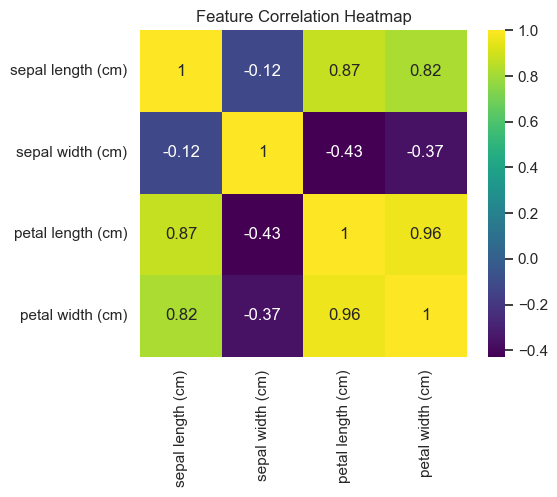

In [17]:
plt.figure(figsize=(6, 5))
corr = X.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='viridis', square=True)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

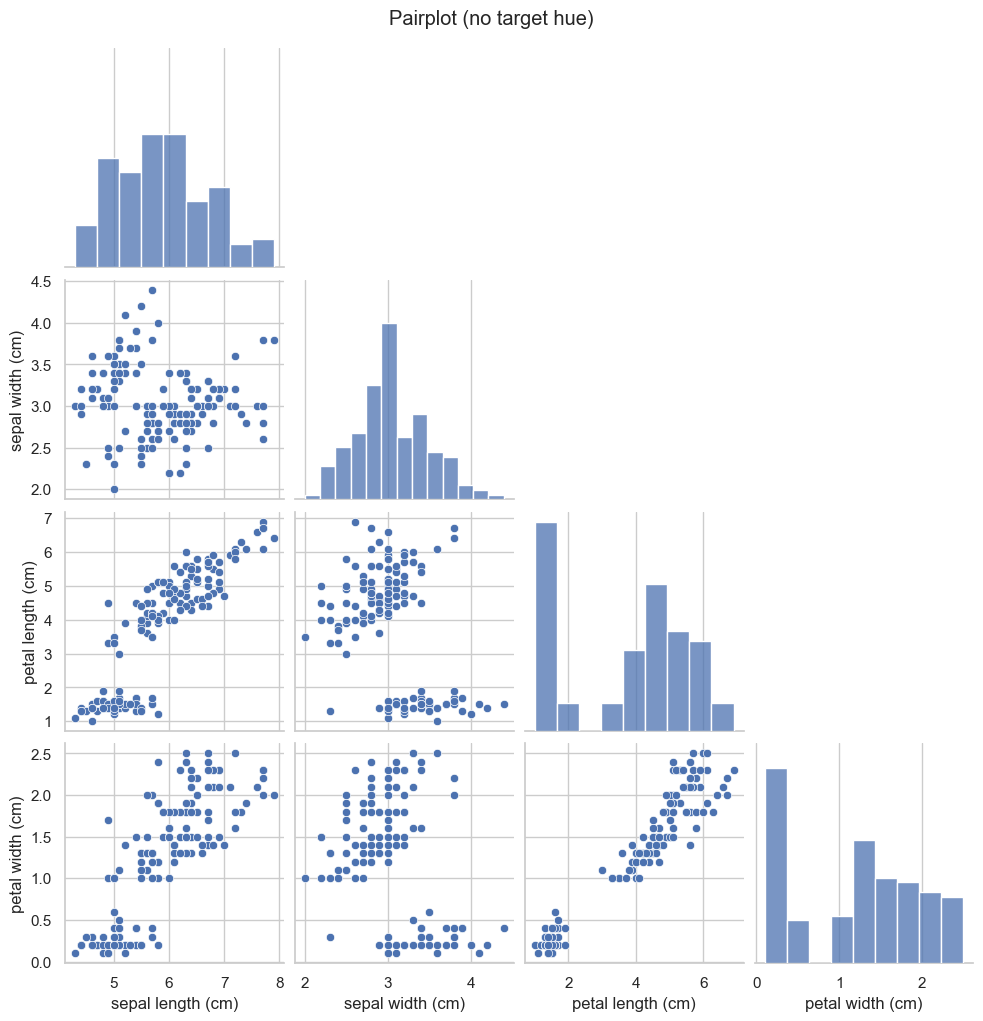

In [18]:
sns.pairplot(X, corner=True, diag_kind='hist')
plt.suptitle('Pairplot (no target hue)', y=1.02)
plt.show()

In [19]:
k_values = list(range(2, 9))
inertias = []
silhouettes = []
calinski_harabasz_scores = []
davies_bouldin_scores = []

for k in k_values:
    model = fit_kmeans(X_scaled, n_clusters=k, random_state=42)
    inertias.append(float(model.inertia_))
    score = score_kmeans(X_scaled, model.labels_)
    silhouettes.append(score['silhouette'])
    calinski_harabasz_scores.append(score['calinski_harabasz'])
    davies_bouldin_scores.append(score['davies_bouldin'])

metrics_df = pd.DataFrame(
    {
        'k': k_values,
        'inertia': inertias,
        'silhouette': silhouettes,
        'calinski_harabasz': calinski_harabasz_scores,
        'davies_bouldin': davies_bouldin_scores,
    }
)

# Elbow proxy: farthest point from the line between first and last inertia points.
ks = metrics_df['k'].to_numpy(dtype=float)
ys = metrics_df['inertia'].to_numpy(dtype=float)
x1, y1 = ks[0], ys[0]
x2, y2 = ks[-1], ys[-1]
denom = np.hypot(y2 - y1, x2 - x1)
if denom == 0:
    elbow_k = int(ks[0])
else:
    distances = np.abs((y2 - y1) * ks - (x2 - x1) * ys + x2 * y1 - y2 * x1) / denom
    elbow_k = int(ks[np.argmax(distances)])

metrics_df['rank_silhouette'] = metrics_df['silhouette'].rank(ascending=False, method='min')
metrics_df['rank_calinski_harabasz'] = metrics_df['calinski_harabasz'].rank(
    ascending=False, method='min'
 )
metrics_df['rank_davies_bouldin'] = metrics_df['davies_bouldin'].rank(
    ascending=True, method='min'
 )
metrics_df['rank_sum'] = (
    metrics_df['rank_silhouette']
    + metrics_df['rank_calinski_harabasz']
    + metrics_df['rank_davies_bouldin']
 )

top_rank = float(metrics_df['rank_sum'].min())
tied = metrics_df.loc[metrics_df['rank_sum'] == top_rank, 'k'].astype(int).tolist()
k_best = elbow_k if elbow_k in tied else tied[0]

print('Elbow k:', elbow_k)
print('Best k by rank consensus (+ elbow tie-break):', k_best)
display(
    metrics_df[
        [
            'k',
            'inertia',
            'silhouette',
            'calinski_harabasz',
            'davies_bouldin',
            'rank_sum',
        ]
    ].round(4)
 )

Elbow k: 3
Best k by rank consensus (+ elbow tie-break): 2


,k,inertia,silhouette,calinski_harabasz,davies_bouldin,rank_sum
0,2,222.3617,0.5818,251.3493,0.5933,3.0
1,3,139.8205,0.4599,241.9044,0.8336,6.0
2,4,114.0923,0.3845,207.2664,0.8772,9.0
3,5,90.8076,0.3455,203.2674,0.9452,13.0
4,6,80.0222,0.3220,187.1401,1.0584,19.0
5,7,71.0334,0.3277,177.4803,0.9900,18.0
6,8,62.5149,0.3417,174.4106,0.9070,16.0


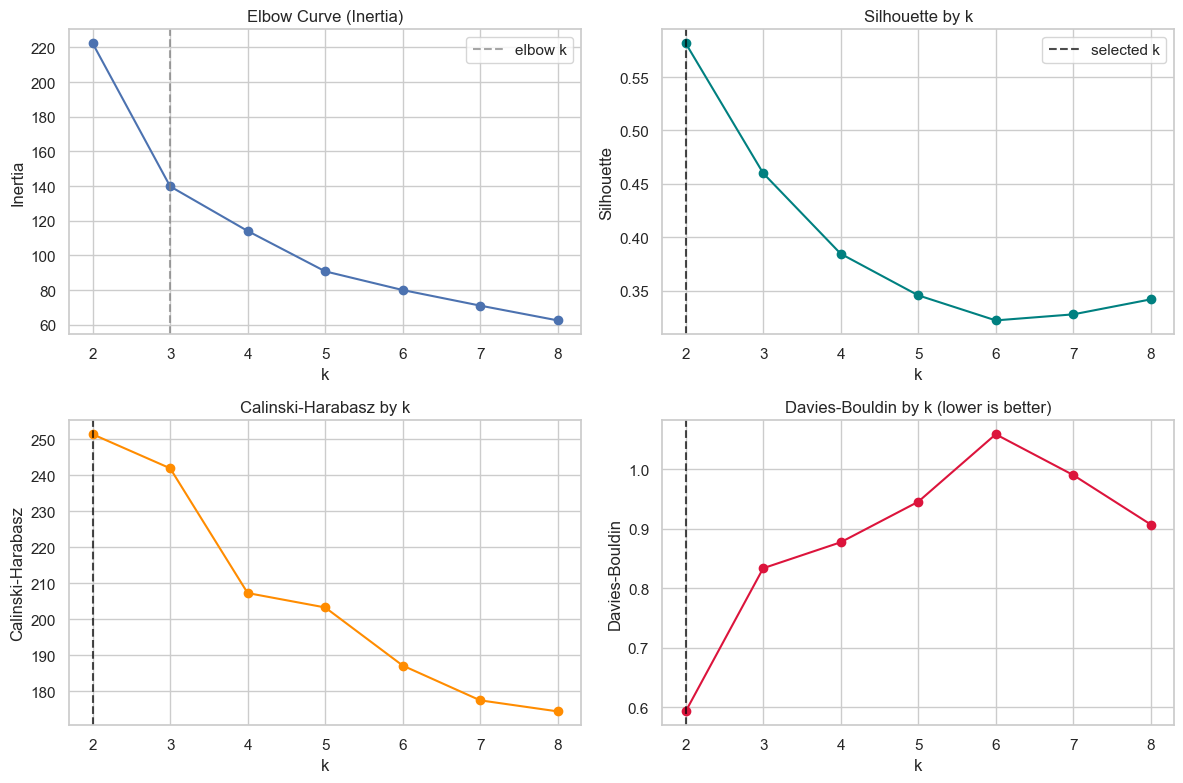

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].plot(k_values, inertias, marker='o')
axes[0, 0].axvline(elbow_k, linestyle='--', color='gray', alpha=0.7, label='elbow k')
axes[0, 0].set_title('Elbow Curve (Inertia)')
axes[0, 0].set_xlabel('k')
axes[0, 0].set_ylabel('Inertia')
axes[0, 0].legend()

axes[0, 1].plot(k_values, silhouettes, marker='o', color='teal')
axes[0, 1].axvline(k_best, linestyle='--', color='black', alpha=0.7, label='selected k')
axes[0, 1].set_title('Silhouette by k')
axes[0, 1].set_xlabel('k')
axes[0, 1].set_ylabel('Silhouette')
axes[0, 1].legend()

axes[1, 0].plot(k_values, calinski_harabasz_scores, marker='o', color='darkorange')
axes[1, 0].axvline(k_best, linestyle='--', color='black', alpha=0.7)
axes[1, 0].set_title('Calinski-Harabasz by k')
axes[1, 0].set_xlabel('k')
axes[1, 0].set_ylabel('Calinski-Harabasz')

axes[1, 1].plot(k_values, davies_bouldin_scores, marker='o', color='crimson')
axes[1, 1].axvline(k_best, linestyle='--', color='black', alpha=0.7)
axes[1, 1].set_title('Davies-Bouldin by k (lower is better)')
axes[1, 1].set_xlabel('k')
axes[1, 1].set_ylabel('Davies-Bouldin')

plt.tight_layout()
plt.show()

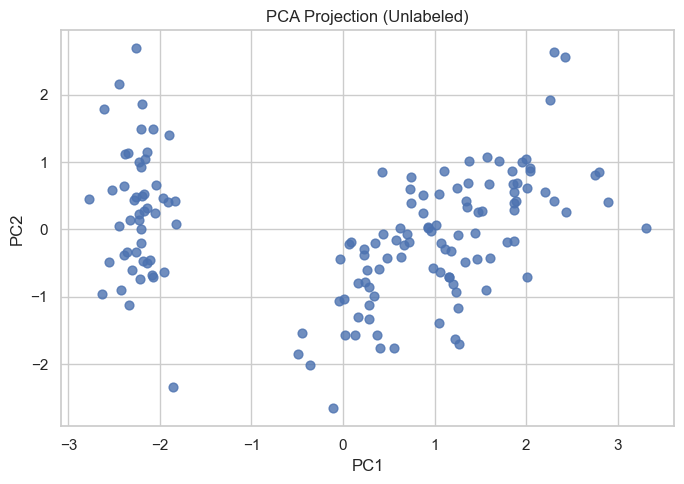

In [21]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(7, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.8, s=40)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA Projection (Unlabeled)')
plt.tight_layout()
plt.show()

In [22]:
final_model = fit_kmeans(X_scaled, n_clusters=k_best, random_state=42)
cluster_labels = final_model.labels_
unsupervised_metrics = score_kmeans(X_scaled, cluster_labels)
pd.Series(unsupervised_metrics, name='value')

silhouette             0.581750
calinski_harabasz    251.349339
davies_bouldin         0.593313
Name: value, dtype: float64

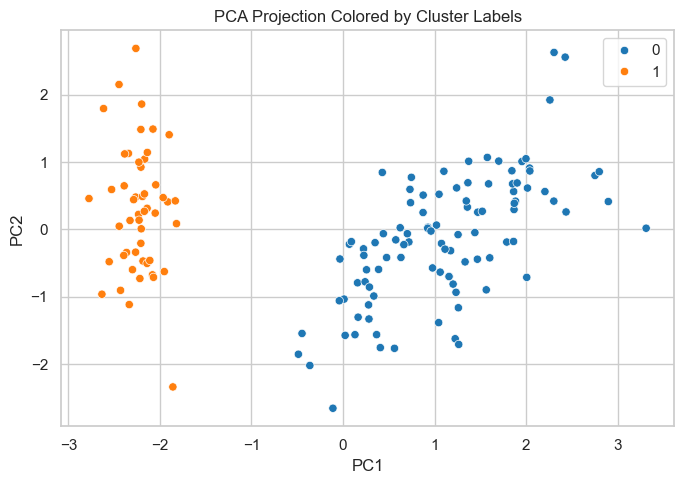

In [23]:
plt.figure(figsize=(7, 5))
sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=cluster_labels,
    palette='tab10',
    legend='full',
)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA Projection Colored by Cluster Labels')
plt.tight_layout()
plt.show()

In [24]:
posthoc = posthoc_label_metrics(
    y_true=y.to_numpy(),
    cluster_labels=cluster_labels,
)

summary = {
    'adjusted_rand_index': posthoc['adjusted_rand_index'],
    'normalized_mutual_info': posthoc['normalized_mutual_info'],
    'v_measure': posthoc['v_measure'],
    'mapped_accuracy': posthoc['mapped_accuracy'],
    'mapped_macro_precision': posthoc['mapped_macro_precision'],
    'mapped_macro_recall': posthoc['mapped_macro_recall'],
    'mapped_macro_f1': posthoc['mapped_macro_f1'],
}

print('Post-hoc metrics (evaluation only):')
for key, value in summary.items():
    print(f'- {key}: {value:.4f}')

report_df = pd.DataFrame(posthoc['mapped_classification_report']).T
report_df

Post-hoc metrics (evaluation only):
- adjusted_rand_index: 0.5681
- normalized_mutual_info: 0.7337
- v_measure: 0.7337
- mapped_accuracy: 0.6667
- mapped_macro_precision: 0.5000
- mapped_macro_recall: 0.6667
- mapped_macro_f1: 0.5556


,precision,recall,f1-score,support
0,1.000000,1.000000,1.000000,50.000000
1,0.500000,1.000000,0.666667,50.000000
2,0.000000,0.000000,0.000000,50.000000
accuracy,0.666667,0.666667,0.666667,0.666667
macro avg,0.500000,0.666667,0.555556,150.000000
weighted avg,0.500000,0.666667,0.555556,150.000000


## Recap

- Model fitting, scaling, PCA, and k selection used only feature data.
- Unsupervised metrics evaluate compactness and separation without labels.
- Target-based metrics are post-hoc diagnostics only and are not used
  for training decisions.